# TerraAlert — Earthquake Dataset EDA
**Dataset:** USGS Earthquake Catalog (2015–2024)  
**Source:** https://earthquake.usgs.gov/fdsnws/event/1/  

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded')

Libraries loaded


## 1. Download Data from USGS Live API

In [16]:
import pandas as pd
import requests
import time

all_dfs = []
years = [2020, 2021, 2022, 2023, 2024]

for year in years:
    url = 'https://earthquake.usgs.gov/fdsnws/event/1/query'
    params = {
        'format': 'csv',
        'starttime': f'{year}-01-01',
        'endtime': f'{year}-12-31',
        'minmagnitude': 5.0,
        'orderby': 'time'
    }
    print(f'Downloading {year}')
    response = requests.get(url, params=params)
    
    if response.status_code == 200:
        from io import StringIO
        df_year = pd.read_csv(StringIO(response.text))
        all_dfs.append(df_year)
        print(f'  {year}: {len(df_year):,} earthquakes')
    else:
        print(f'  {year}: Error {response.status_code}')
    
    time.sleep(1)  # be polite to the API

df = pd.concat(all_dfs, ignore_index=True)
df.to_csv('../data/earthquakes/usgs_earthquakes.csv', index=False)
print(f'\nTotal records saved: {len(df):,}')

  2020: 1,448 earthquakes
  2021: 2,223 earthquakes
  2022: 1,725 earthquakes
  2023: 1,778 earthquakes
  2024: 1,504 earthquakes

Total records saved: 8,678


In [9]:
df = pd.read_csv('../data/earthquakes/usgs_earthquakes.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (8678, 22)
Columns: ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource']


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2020-12-30T05:33:43.546Z,34.7410,72.9466,10.00,5.0,mb,NaN,42.0,1.119,1.18,...,2021-03-06T23:20:35.040Z,"7 km NNW of Shingli Bala, Pakistan",earthquake,6.4,1.8,0.071,63.0,reviewed,us,us
1,2020-12-30T00:35:27.718Z,36.4858,140.6097,43.47,5.0,mww,NaN,42.0,1.934,0.91,...,2025-12-22T19:06:20.183Z,"4 km ENE of Funaishikawa, Japan",earthquake,6.9,4.9,0.098,10.0,reviewed,us,us
2,2020-12-29T23:34:57.647Z,-0.7603,-21.1005,10.00,5.7,mww,NaN,46.0,9.629,0.72,...,2025-12-22T17:59:41.811Z,central Mid-Atlantic Ridge,earthquake,4.3,1.8,0.065,23.0,reviewed,us,us
3,2020-12-29T16:21:48.131Z,5.2608,125.2951,35.00,5.3,mww,NaN,36.0,1.819,1.07,...,2025-12-22T18:47:33.713Z,"24 km SW of Sarangani, Philippines",earthquake,5.7,1.9,0.078,16.0,reviewed,us,us
4,2020-12-29T11:19:54.762Z,45.4244,16.2573,10.00,6.4,mww,NaN,13.0,0.941,0.75,...,2025-12-22T19:05:20.622Z,"2 km WSW of Petrinja, Croatia",earthquake,4.4,1.8,0.033,89.0,reviewed,us,us


## 2. Data Quality Check

In [10]:
print('=== DATASET OVERVIEW ===')
print(f'Total records: {len(df):,}')
print(f'Date range: {df["time"].min()} → {df["time"].max()}')
print(f'\nNull values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nMagnitude stats:')
print(df['mag'].describe())

=== DATASET OVERVIEW ===
Total records: 8,678
Date range: 2020-01-01T00:28:20.289Z → 2024-12-30T05:49:02.808Z

Null values:
nst                4263
gap                  81
dmin                 85
rms                  31
horizontalError      89
magError             84
magNst               92
dtype: int64

Magnitude stats:
count    8678.000000
mean        5.327510
std         0.395968
min         5.000000
25%         5.000000
50%         5.200000
75%         5.500000
max         8.200000
Name: mag, dtype: float64


## 3. Exploratory Analysis

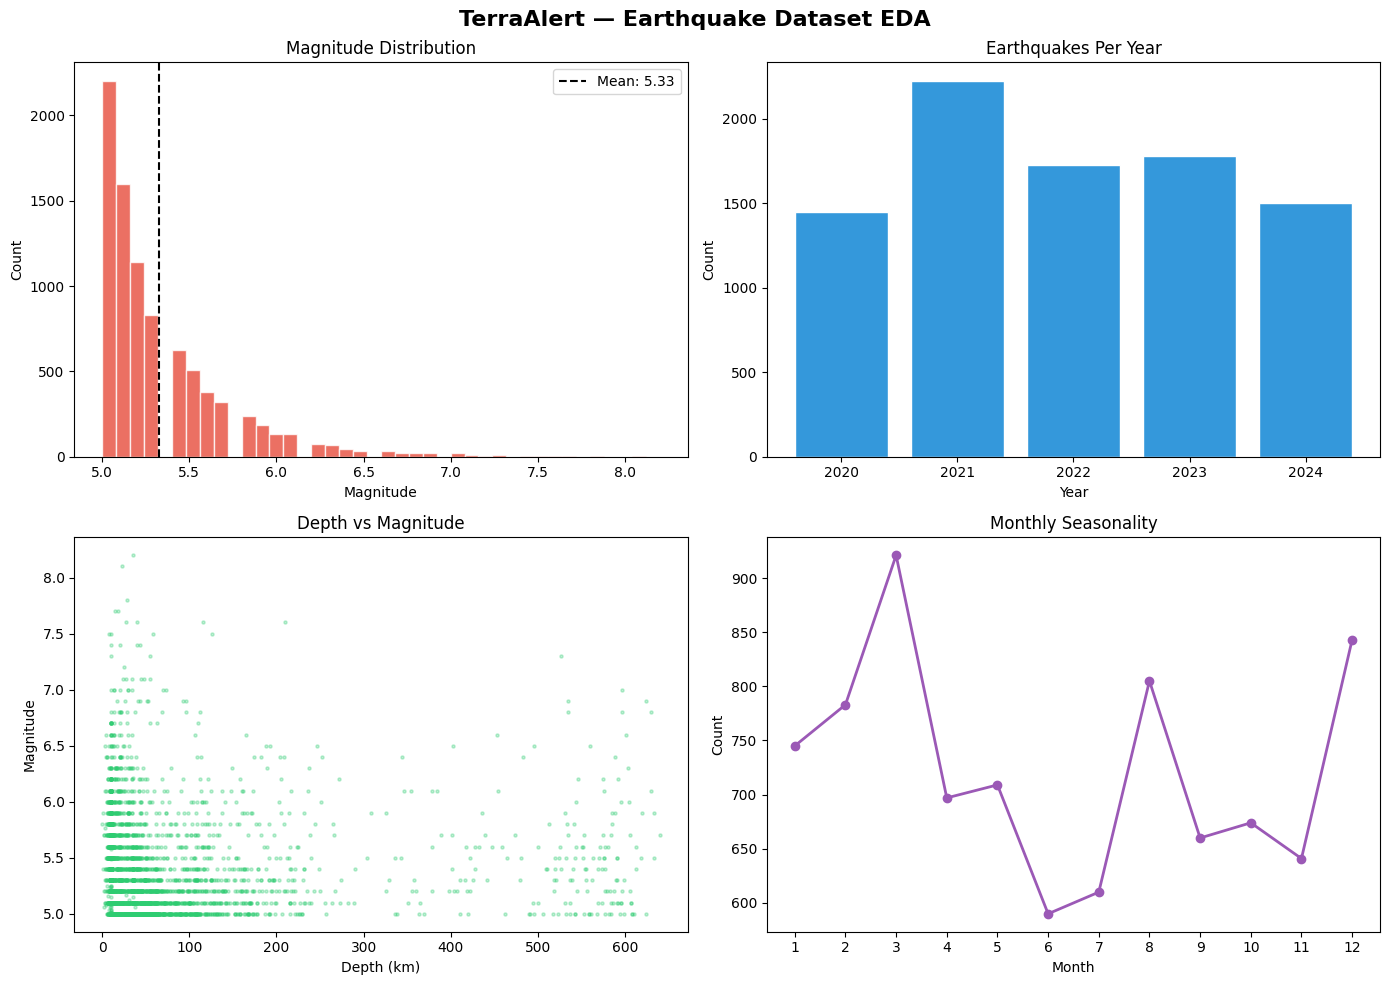

Plots saved 


In [17]:
df['time'] = pd.to_datetime(df['time'])
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['depth'] = pd.to_numeric(df['depth'], errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('TerraAlert — Earthquake Dataset EDA', fontsize=16, fontweight='bold')

# Plot 1: Magnitude distribution
axes[0,0].hist(df['mag'].dropna(), bins=40, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Magnitude Distribution')
axes[0,0].set_xlabel('Magnitude')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(df['mag'].mean(), color='black', linestyle='--', label=f'Mean: {df["mag"].mean():.2f}')
axes[0,0].legend()

# Plot 2: Earthquakes per year
yearly = df.groupby('year').size()
axes[0,1].bar(yearly.index, yearly.values, color='#3498db', edgecolor='white')
axes[0,1].set_title('Earthquakes Per Year')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Count')

# Plot 3: Depth vs Magnitude
sample = df.sample(min(5000, len(df)))
axes[1,0].scatter(sample['depth'], sample['mag'], alpha=0.3, color='#2ecc71', s=5)
axes[1,0].set_title('Depth vs Magnitude')
axes[1,0].set_xlabel('Depth (km)')
axes[1,0].set_ylabel('Magnitude')

# Plot 4: Monthly seasonality
monthly = df.groupby('month').size()
axes[1,1].plot(monthly.index, monthly.values, marker='o', color='#9b59b6', linewidth=2)
axes[1,1].set_title('Monthly Seasonality')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Count')
axes[1,1].set_xticks(range(1,13))

plt.tight_layout()
plt.savefig('../data/earthquakes/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plots saved ')

In [12]:
# Geographic heatmap data prep
print('Top 10 most seismically active regions:')
df['rounded_lat'] = df['latitude'].round(0)
df['rounded_lon'] = df['longitude'].round(0)
hotspots = df.groupby(['rounded_lat','rounded_lon']).size().reset_index(name='count')
print(hotspots.sort_values('count', ascending=False).head(10))

Top 10 most seismically active regions:
      rounded_lat  rounded_lon  count
586         -23.0        172.0    114
466         -29.0       -177.0    107
1634         24.0        122.0     91
455         -30.0       -177.0     89
585         -23.0        171.0     80
56          -60.0        -26.0     79
1333          8.0        127.0     74
66          -59.0        -25.0     73
1349          9.0        127.0     71
78          -58.0        -25.0     55


## 4. Model Justification

**For this earthquake dataset, I will compare:**

| Model | Reason |
|---|---|
| **LSTM** | Baseline — classic time-series model, well-established for sequential seismic data |
| **Temporal Fusion Transformer (TFT)** | State-of-the-art (Google, 2021) — handles multi-horizon forecasting, attention mechanism explains which past events influence future magnitude |

**Target variable:** Predict magnitude of next earthquake in a region given last N events  
**Features:** time delta between events, depth, latitude, longitude, rolling mean magnitude  
**Evaluation metrics:** RMSE, MAE, R²  
**Expected outcome:** TFT outperforms LSTM due to attention over variable-length sequences


In [13]:
# Feature engineering preview for model training phase
df_sorted = df.sort_values('time')
df_sorted['time_delta'] = df_sorted['time'].diff().dt.total_seconds() / 3600  # hours
df_sorted['mag_rolling_mean_10'] = df_sorted['mag'].rolling(10).mean()
df_sorted['mag_rolling_std_10'] = df_sorted['mag'].rolling(10).std()
df_sorted['depth_normalized'] = (df_sorted['depth'] - df_sorted['depth'].mean()) / df_sorted['depth'].std()

features = ['time_delta', 'mag_rolling_mean_10', 'mag_rolling_std_10', 'depth_normalized', 'latitude', 'longitude']
df_model_ready = df_sorted[features + ['mag']].dropna()

print(f'Model-ready dataset shape: {df_model_ready.shape}')
print(f'Features: {features}')
df_model_ready.head()

Model-ready dataset shape: (8669, 7)
Features: ['time_delta', 'mag_rolling_mean_10', 'mag_rolling_std_10', 'depth_normalized', 'latitude', 'longitude']


,time_delta,mag_rolling_mean_10,mag_rolling_std_10,depth_normalized,latitude,longitude,mag
1438,5.270127,5.15,0.201384,-0.417886,34.1326,60.2681,5.5
1437,0.998115,5.14,0.206559,-0.062092,9.5255,138.1431,5.0
1436,3.425913,5.14,0.206559,-0.385613,55.5493,-151.4274,5.0
1435,2.508690,5.16,0.241293,-0.417886,-5.7527,124.9760,5.6
1434,2.273356,5.18,0.234758,-0.417886,-9.6778,159.9214,5.2


In [18]:
df_model_ready.to_csv('../data/earthquakes/earthquakes_processed.csv', index=False)
print('Processed dataset saved ')
print(f'\nCheckpoint 1 Summary:')
print(f'  Raw records: {len(df):,}')
print(f'  Model-ready records: {len(df_model_ready):,}')
print(f'  Features engineered: {len(features)}')
print(f'  Next step: Train LSTM vs TFT in notebook 04_earthquake_models.ipynb')

Processed dataset saved 

Checkpoint 1 Summary:
  Raw records: 8,678
  Model-ready records: 8,669
  Features engineered: 6
  Next step: Train LSTM vs TFT in notebook 04_earthquake_models.ipynb
